In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap


c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_pickle('engineered_chicago_crime_data.pkl')

In [65]:
df.head()

,Date,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Year,Latitude,Longitude,...,Hour,Is_Weekend,Season,Lat_bin,Lon_bin,Crime_Severity_Score,Location_Desc_freq,Primary Type_freq,Latitude_Norm,Longitude_Norm
0,2026-03-18,2,16,0,1,332,5,2026,41.768797,-87.584413,...,0,0,1,"(41.758, 41.777]","(-87.586, -87.566]",3,0.194385,0.180824,-0.898721,1.418079
1,2026-03-18,29,130,0,0,411,8,2026,41.745255,-87.584152,...,0,0,1,"(41.739, 41.758]","(-87.586, -87.566]",1,0.015273,0.234081,-1.171113,1.422509
2,2026-03-18,29,103,0,0,1732,30,2026,41.943437,-87.721197,...,0,0,1,"(41.928, 41.947]","(-87.73, -87.709]",1,0.119159,0.234081,1.121917,-0.900134
4,2026-03-18,8,103,0,0,735,17,2026,41.762156,-87.673463,...,0,0,1,"(41.758, 41.777]","(-87.689, -87.668]",2,0.119159,0.057381,-0.975564,-0.091136
5,2026-03-18,3,119,0,0,1733,33,2026,41.940161,-87.701524,...,0,0,1,"(41.928, 41.947]","(-87.709, -87.689]",2,0.267355,0.038438,1.084011,-0.566714


In [84]:
# Drop non-useful columns
drop_cols = ['Latitude', 'Longitude', 'Lat_bin', 'Lon_bin', 'Primary Type'] 
df_model = df.drop(columns=drop_cols)

# If any object columns remain
df_model = df_model.select_dtypes(include=['int64', 'float64'])

# Separate features
X = df_model.copy()

In [85]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [86]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [87]:
X_scaled_df.head()

,Location Description,Arrest,Domestic,Beat,Ward,Year,District,Community Area,Day_of_Week,Is_Weekend,Season,Crime_Severity_Score,Location_Desc_freq,Latitude_Norm,Longitude_Norm
0,-1.600107,-0.420432,2.074489,-1.153081,-1.299009,2.145264,-1.166640,0.310520,-0.509512,-0.638071,-0.412538,0.947142,0.593454,-0.898721,1.418079
1,1.130619,-0.420432,-0.482046,-1.041536,-1.083653,2.145264,-1.025339,0.403325,-0.509512,-0.638071,-0.412538,-1.127472,-1.119323,-1.171113,1.422509
2,0.483868,-0.420432,-0.482046,0.823660,0.495630,2.145264,0.811574,-0.710334,-0.509512,-0.638071,-0.412538,-1.127472,-0.125902,1.121917,-0.900134
4,0.483868,-0.420432,-0.482046,-0.584062,-0.437582,2.145264,-0.601436,1.424178,-0.509512,-0.638071,-0.412538,-0.090165,-0.125902,-0.975564,-0.091136
5,0.867128,-0.420432,-0.482046,0.825072,0.710987,2.145264,0.811574,-0.710334,-0.509512,-0.638071,-0.412538,-0.090165,1.291243,1.084011,-0.566714


In [88]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

In [89]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(explained_variance)

[0.26891148 0.38895994 0.47989979 0.5660672  0.63970027 0.70792564
 0.76652801 0.82345451 0.87092408 0.91307206 0.9520721  0.97597885
 0.99007886 0.99998933 1.        ]


In [90]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_df)

In [91]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
print(explained_variance)

[0.26891148 0.38895994 0.47989979]


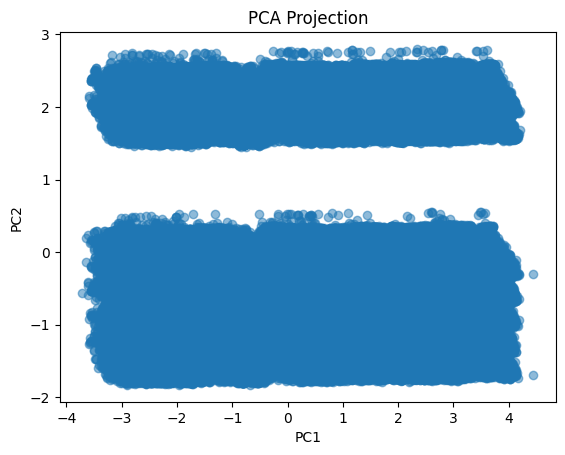

In [92]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

In [93]:
loadings = pca.components_.T

feature_importance = np.abs(loadings[:, 0])  # PC1 importance

feature_names = X.columns

importance_df = sorted(
    zip(feature_names, feature_importance),
    key=lambda x: x[1],
    reverse=True
)

print("Top 5 Features:")
for f in importance_df[:5]:
    print(f)

Top 5 Features:
('District', np.float64(0.4441698092357061))
('Beat', np.float64(0.4438516481743505))
('Latitude_Norm', np.float64(0.4368031712920565))
('Ward', np.float64(0.4189769481635776))
('Community Area', np.float64(0.3509864958658903))


In [94]:
X_scaled_df_sample = X_scaled_df.sample(10000, random_state=42)

In [96]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_df_sample)

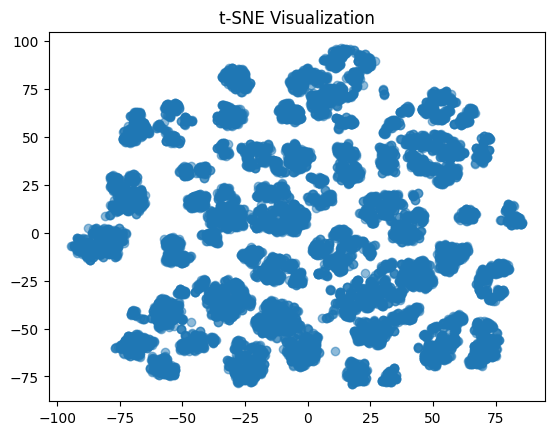

In [97]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5)
plt.title("t-SNE Visualization")
plt.show()

In [98]:
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled_df_sample)

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


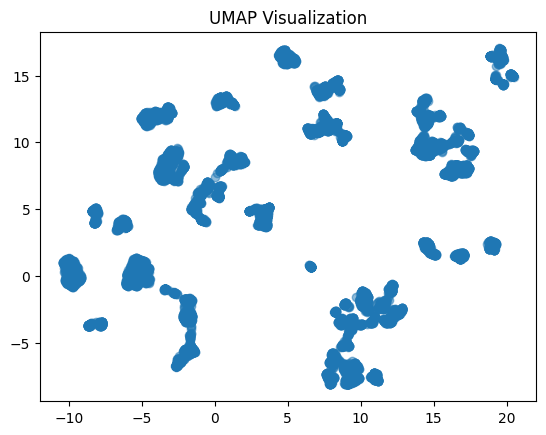

In [99]:
plt.scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5)
plt.title("UMAP Visualization")
plt.show()

In [38]:
# Visualizig Crime Clusters in lower dimentional space

In [66]:
lable_data = pd.read_pickle('cleaned_chicago_crime_data.pkl')

lable_data_sample = lable_data.loc[X_scaled_df_sample.index]

In [67]:
lable_data_sample.head()

,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,...,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Location,ID,District,Community Area,Updated On
144626,JJ350415,2025-07-26 13:00:00,032XX N CLARK ST,1320,CRIMINAL DAMAGE,TO VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,1924,...,1169823.0,1921702.0,2025,41.940653,-87.651245,POINT (-87.651244814 41.940652722),13914235,19,6,2026-03-14 15:41:39
55846,JJ515223,2025-12-08 11:50:00,011XX N LAVERGNE AVE,0420,BATTERY,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,SIDEWALK,False,False,1531,...,1142821.0,1907169.0,2025,41.901319,-87.750850,POINT (-87.750850275 41.901319345),14050615,15,25,2026-03-14 15:41:39
336105,JH459342,2024-10-07 15:41:00,0000X N STATE ST,1150,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,DEPARTMENT STORE,False,False,112,...,1176365.0,1900502.0,2024,41.882334,-87.627842,POINT (-87.627841791 41.88233367),13623261,1,32,2025-05-17 15:40:52
179270,JJ317928,2025-06-08 11:35:00,086XX S COTTAGE GROVE AVE,0860,THEFT,RETAIL THEFT,STREET,False,False,632,...,1183071.0,1847869.0,2025,41.737751,-87.604856,POINT (-87.604855911 41.737750767),13887382,6,44,2026-03-14 15:41:39
113922,JJ407371,2025-09-09 02:20:00,032XX W WILSON AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,STREET,True,True,1724,...,1153790.0,1930339.0,2025,41.964688,-87.709941,POINT (-87.709940966 41.964688189),13961019,17,14,2026-03-14 15:41:39


In [68]:
X_scaled_df_sample.head()

,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Year,District,Community Area,Day_of_Week,Is_Weekend,Season,Crime_Severity_Score,Location_Desc_freq,Latitude_Norm,Longitude_Norm
144626,-0.779873,0.340146,-0.420432,-0.482046,1.094756,1.500629,0.562945,1.094176,-1.406370,0.989337,1.567225,0.510534,-0.090165,-0.928980,1.089700,0.285416
55846,-1.043247,0.771313,-0.420432,-0.482046,0.539857,0.998130,0.562945,0.528972,-0.524724,-1.508745,-0.638071,1.433607,0.947142,-0.767998,0.634600,-1.402692
336105,-0.516499,-0.522189,-0.420432,-0.482046,-1.463712,0.782773,-1.019375,-1.449242,-0.199907,-1.508745,-0.638071,-1.335610,-0.090165,-1.041774,0.414930,0.682049
179270,1.327120,0.867128,-0.420432,-0.482046,-0.729493,-1.227224,0.562945,-0.742737,0.356922,1.488954,1.567225,0.510534,-1.127472,1.291243,-1.257940,1.071612
113922,0.712580,0.867128,2.378505,2.074489,0.812365,0.710987,0.562945,0.811574,-1.035151,-1.009128,-0.638071,-1.335610,-1.127472,1.291243,1.367798,-0.709363


In [70]:
(X_scaled_df_sample.index == lable_data_sample.index).all()

np.True_

In [100]:
import plotly.express as px
import pandas as pd

# Create dataframe for plotting
plot_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'Crime_Type': lable_data_sample['Primary Type'],
    'Severity': X_scaled_df_sample['Crime_Severity_Score']
})

fig = px.scatter(
    plot_df,
    x='UMAP1',
    y='UMAP2',
    color='Crime_Type',   # or Severity
    title='UMAP Crime Clusters (Interactive)',
)

fig.show()

In [101]:
umap_3d = umap.UMAP(n_components=3, random_state=42)
X_umap_3d = umap_3d.fit_transform(X_scaled_df_sample)

plot_df['UMAP3'] = X_umap_3d[:, 2]

fig = px.scatter_3d(
    plot_df,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='Crime_Type'
)

fig.show()

c:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
